In [ ]:
import pandas as pd
import numpy as np

from tools import evaluate_model

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [23]:
X_train = pd.read_pickle(r"..\data\processed\X_train_clean.pkl")
X_test = pd.read_pickle(r"..\data\processed\X_test_clean.pkl")
y_train = pd.read_pickle(r"..\data\processed\y_train.pkl")
y_test = pd.read_pickle(r"..\data\processed\y_test.pkl")

In [24]:
param_grid = {
    'C': np.logspace(-4, 3, 8)
}

gridSearch = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid,
    scoring='recall',
    refit=True,
    cv=5,
    n_jobs=-1
)

gridSearch.fit(X_train, y_train)

gridSearch.best_params_

{'C': np.float64(0.1)}

In [25]:
model = gridSearch.best_estimator_

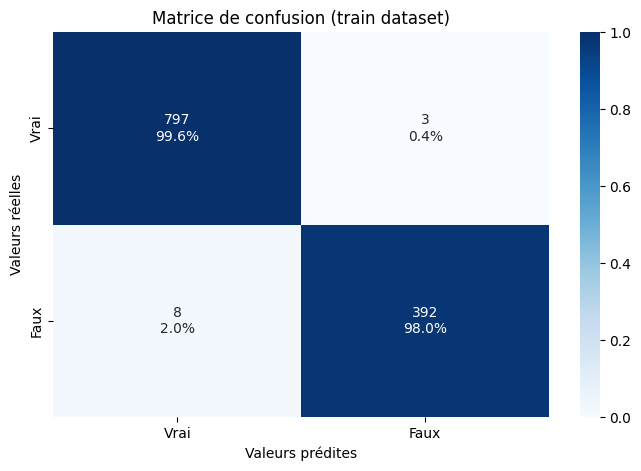

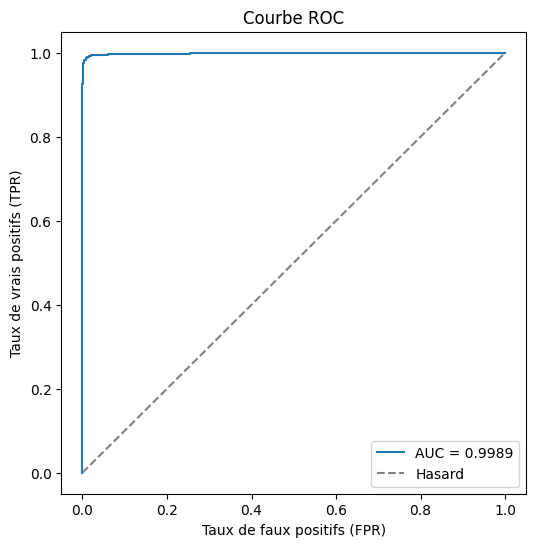

recall_score : 98.00%


In [26]:
_ = evaluate_model(model, X_train, y_train, ["Vrai", "Faux"], "recall", "Matrice de confusion (train dataset)")

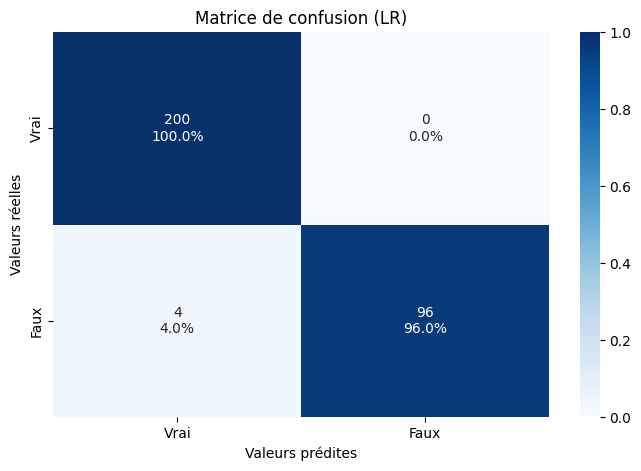

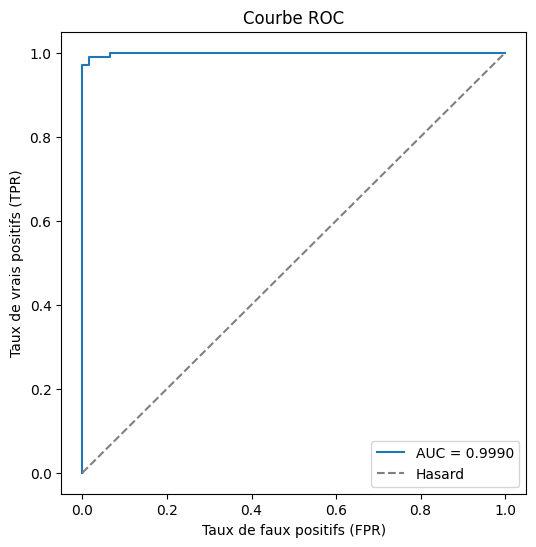

recall_score : 96.00%


In [27]:
_ = evaluate_model(model, X_test, y_test, ["Vrai", "Faux"], "recall", "Matrice de confusion (LR)")